# 04 — Maps

Choropleths of archetype abundances at region / province / municipality level.
Region shapes are the province shapefile dissolved with the data's own
province→region assignment (post-2024 regions render correctly).

Municipality maps need `data/shapefiles/municipalities.geojson`
(`python scripts/fetch_boundaries.py`).

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [2]:
from src.aggregation import aggregate_abundances, dominant_archetype
from src.data.loading import load_processed
from src.figures import plot_choropleth
from src.geo import (join_municipalities, join_provinces, join_regions,
                     load_municipalities, load_provinces)

endmembers, abundances_df, meta = load_processed(config)
arch_cols = list(endmembers.columns)
provinces = load_provinces(config)
print(f'{len(provinces)} province shapes')

81 province shapes


## Region level

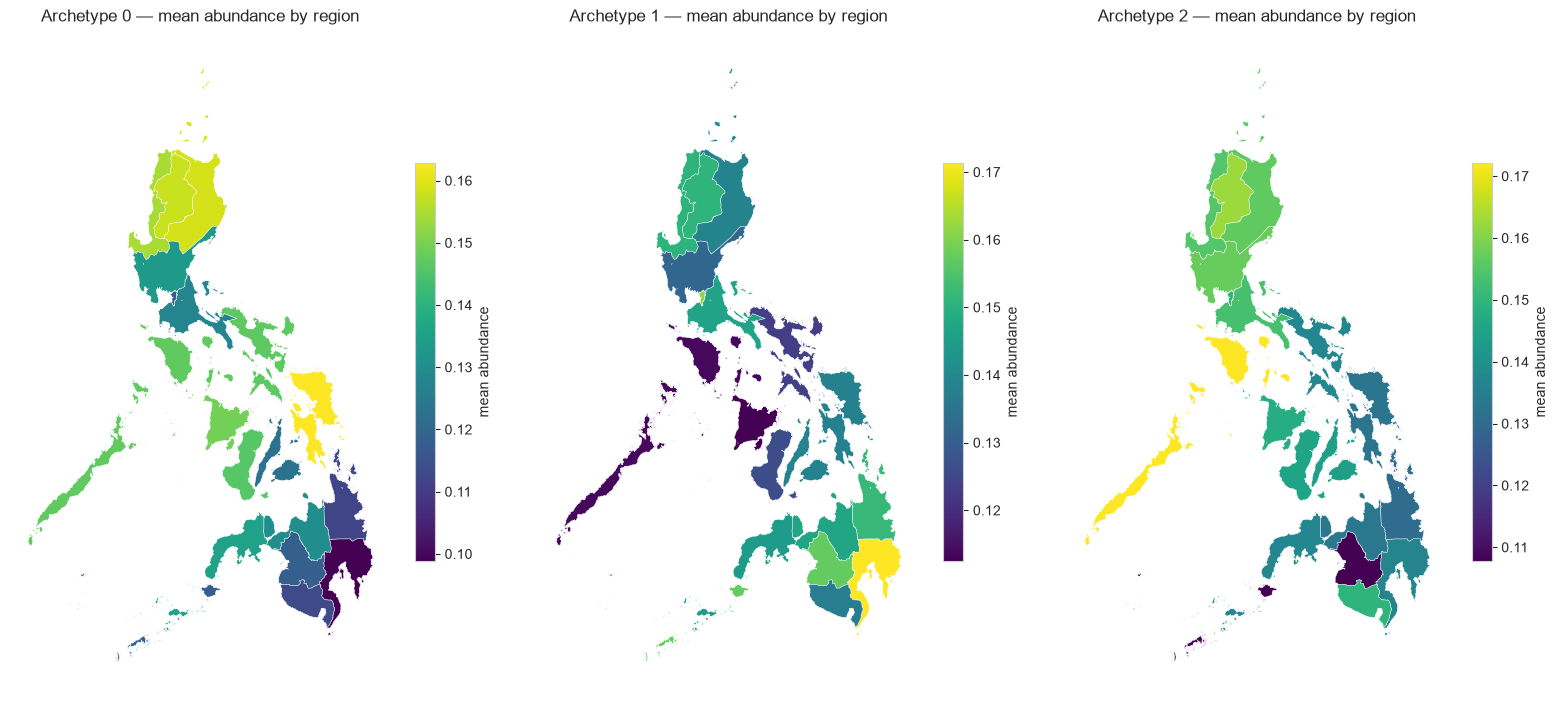

In [3]:
agg_prov = aggregate_abundances(abundances_df, level='province')
agg_reg = aggregate_abundances(abundances_df, level='region')

gdf_reg, unmatched = join_regions(agg_prov, provinces, agg_reg)
if unmatched:
    print('provinces without a boundary match:', unmatched)

fig, axes = plt.subplots(1, min(3, len(arch_cols)), figsize=(16, 7))
for j, ax in enumerate(np.atleast_1d(axes)):
    plot_choropleth(gdf_reg, arch_cols[j], ax=ax,
                    title=f'Archetype {j} — mean abundance by region',
                    legend_label='mean abundance')
fig.tight_layout()

## Province level

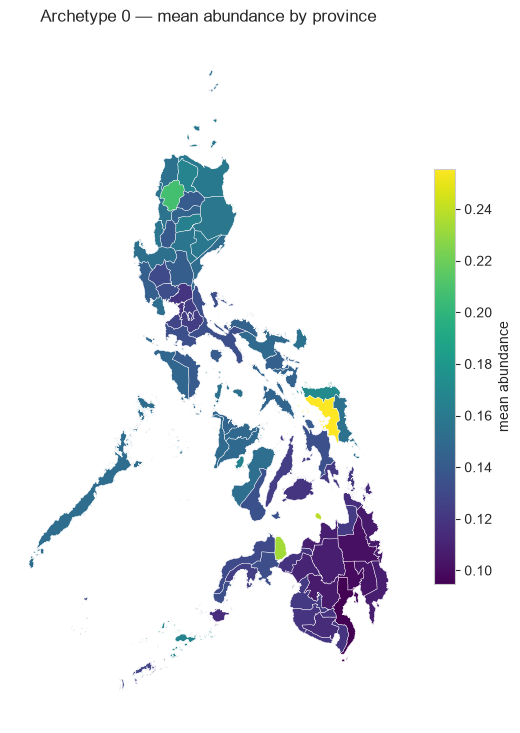

In [4]:
agg_p = aggregate_abundances(abundances_df, level='province')
gdf_prov, unmatched = join_provinces(agg_p, provinces)
if unmatched:
    print('unmatched provinces:', unmatched)

plot_choropleth(gdf_prov, arch_cols[0],
                title='Archetype 0 — mean abundance by province',
                legend_label='mean abundance');

## Dominant archetype per province

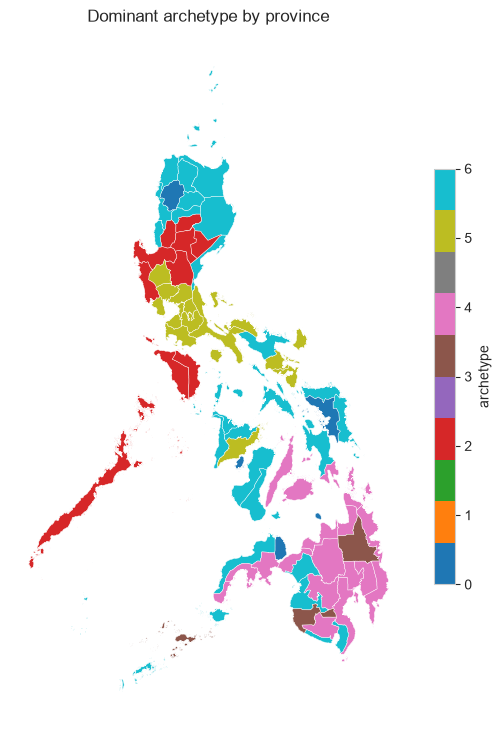

In [5]:
gdf_prov['dominant'] = dominant_archetype(gdf_prov, arch_cols)
plot_choropleth(gdf_prov, 'dominant', cmap='tab10',
                title='Dominant archetype by province',
                legend_label='archetype');

## Municipality level (if boundaries are downloaded)

matched 99.1% of municipalities


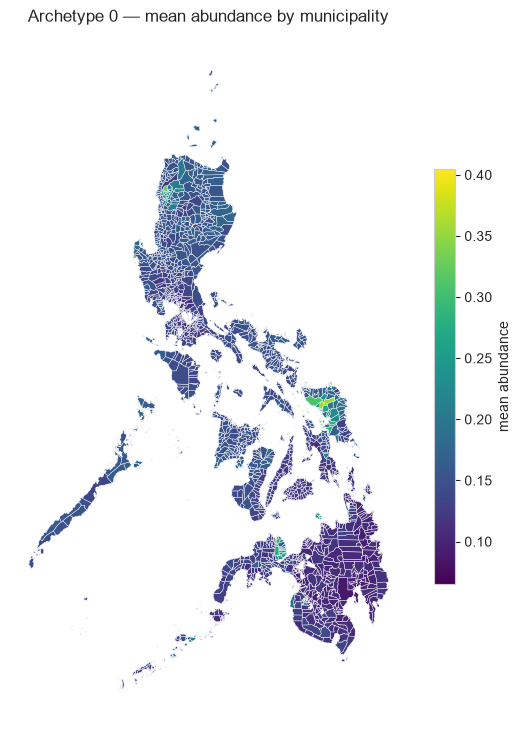

In [6]:
municipalities = load_municipalities(config)
if municipalities is None:
    print('municipalities.geojson missing — run scripts/fetch_boundaries.py')
else:
    agg_m = aggregate_abundances(abundances_df, level='municipality')
    gdf_muni, rate, unmatched_df = join_municipalities(agg_m, municipalities)
    print(f'matched {rate:.1%} of municipalities')
    plot_choropleth(gdf_muni, arch_cols[0],
                    title='Archetype 0 — mean abundance by municipality',
                    legend_label='mean abundance')

## Turnout map

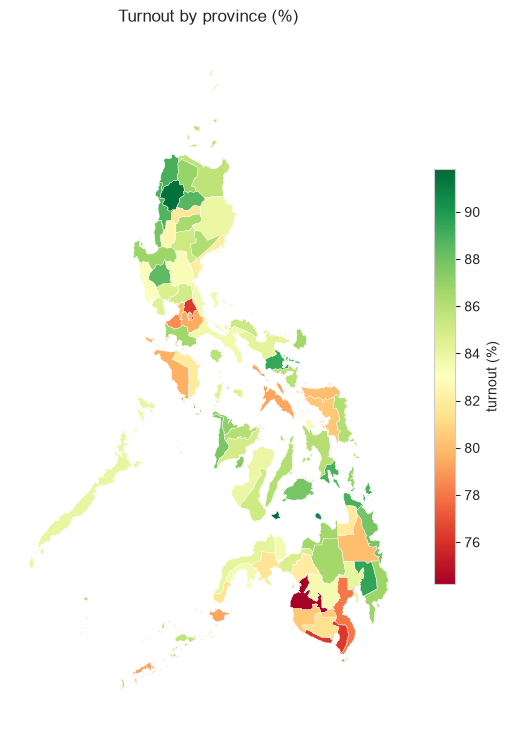

In [7]:
agg_p2 = aggregate_abundances(abundances_df, level='province')
agg_p2['turnout_pct'] = (100 * agg_p2['information.numberOfActuallyVoters']
                         / agg_p2['information.numberOfRegisteredVoters'])
gdf_t, _ = join_provinces(agg_p2, provinces)
plot_choropleth(gdf_t, 'turnout_pct', cmap='RdYlGn',
                title='Turnout by province (%)', legend_label='turnout (%)');